## Gene-set overlap

In [14]:
import scanpy as sc
import pandas as pd
import numpy as np
import scipy.sparse as sp
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [3]:
BASE = "/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune"
OUT_DIR = f"{BASE}/results/09_HIHAtlas"

In [2]:
genes_gbmap = pd.read_csv("/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/04_NMF_GSEAonHGNC/04_3_nmf_all_gsea_c7/genes.csv")
genes_hiha = pd.read_csv("/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/09_HIHAtlas/09_03_nmf_downsampled/genes.csv")

In [4]:
print(genes_gbmap["gene"].str.startswith("ENSG").sum(), "/", len(genes_gbmap))
print(genes_hiha["gene"].str.startswith("ENSG").sum(), "/", len(genes_hiha))

31 / 12442
5 / 665


#### build gene sets per MP for each dataset

In [5]:
SELECTED_MPS = ["MP1", "MP2", "MP7", "MP8", "MP9", "MP11", "MP14", "MP15", "MP19", "MP20"]
genes_gbmap_selected = genes_gbmap[genes_gbmap["mp"].isin(SELECTED_MPS)]

In [6]:

gbmap_mp_genes = {mp: set(df["gene"]) for mp, df in genes_gbmap_selected.groupby("mp")}
hiha_mp_genes = {mp: set(df["gene"]) for mp, df in genes_hiha.groupby("mp")}

print("GBMap MPs (selected only):", sorted(gbmap_mp_genes.keys()))
print("HIHA MPs:", sorted(hiha_mp_genes.keys()))

GBMap MPs (selected only): ['MP1', 'MP11', 'MP14', 'MP15', 'MP19', 'MP2', 'MP20', 'MP7', 'MP8', 'MP9']
HIHA MPs: ['MP1', 'MP2', 'MP3', 'MP4', 'MP5', 'MP6', 'MP7', 'MP8']


In [7]:
# per-MP gene counts, side by side
gbmap_counts = genes_gbmap.groupby("mp").size().rename("gbmap_n_genes")
hiha_counts = genes_hiha.groupby("mp").size().rename("hiha_n_genes")
print(gbmap_counts)
print(hiha_counts)

mp
MP1       55
MP10       2
MP11      94
MP12      10
MP13       2
MP14      71
MP15     222
MP16       9
MP17     798
MP18      63
MP19      17
MP2       41
MP20      36
MP21       2
MP22      10
MP23     571
MP24      43
MP25      33
MP26    9851
MP27      24
MP28       2
MP29     312
MP3        6
MP30       3
MP4       13
MP5        8
MP6       60
MP7       28
MP8       30
MP9       26
Name: gbmap_n_genes, dtype: int64
mp
MP1     74
MP2     14
MP3     15
MP4     57
MP5     38
MP6     18
MP7     77
MP8    372
Name: hiha_n_genes, dtype: int64


#### pairwise overlap-coefficient matrix

In [8]:
overlap_matrix = pd.DataFrame(
    index=sorted(hiha_mp_genes.keys(), key=lambda x: int("".join(ch for ch in x if ch.isdigit()))),
    columns=sorted(gbmap_mp_genes.keys(), key=lambda x: int("".join(ch for ch in x if ch.isdigit()))),
    dtype=float,
)
overlap_counts = pd.DataFrame(
    index=overlap_matrix.index,
    columns=overlap_matrix.columns,
    dtype=object,
)

for hiha_mp, hiha_genes in hiha_mp_genes.items():
    for gb_mp, gb_genes in gbmap_mp_genes.items():
        intersection = hiha_genes & gb_genes
        smaller_size = min(len(hiha_genes), len(gb_genes))
        pct_overlap = len(intersection) / smaller_size if smaller_size > 0 else 0.0

        overlap_matrix.loc[hiha_mp, gb_mp] = pct_overlap
        overlap_counts.loc[hiha_mp, gb_mp] = f"{len(intersection)}/{smaller_size}"

overlap_matrix = overlap_matrix.astype(float)
print(overlap_matrix.round(3))

       MP1    MP2    MP7    MP8    MP9   MP11   MP14   MP15   MP19   MP20
MP1  0.000  0.000  0.036  0.067  0.231  0.000  0.113  0.081  0.000  0.139
MP2  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.643  0.000
MP3  0.000  0.600  0.000  0.000  0.000  0.000  0.067  0.067  0.000  0.000
MP4  0.018  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000
MP5  0.000  0.000  0.000  0.000  0.000  0.000  0.079  0.000  0.235  0.000
MP6  0.222  0.389  0.000  0.000  0.000  0.000  0.000  0.000  0.059  0.000
MP7  0.000  0.024  0.000  0.033  0.000  0.779  0.000  0.000  0.000  0.000
MP8  0.364  0.390  0.071  0.067  0.115  0.011  0.127  0.068  0.529  0.111


#### Heatmap

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
import os

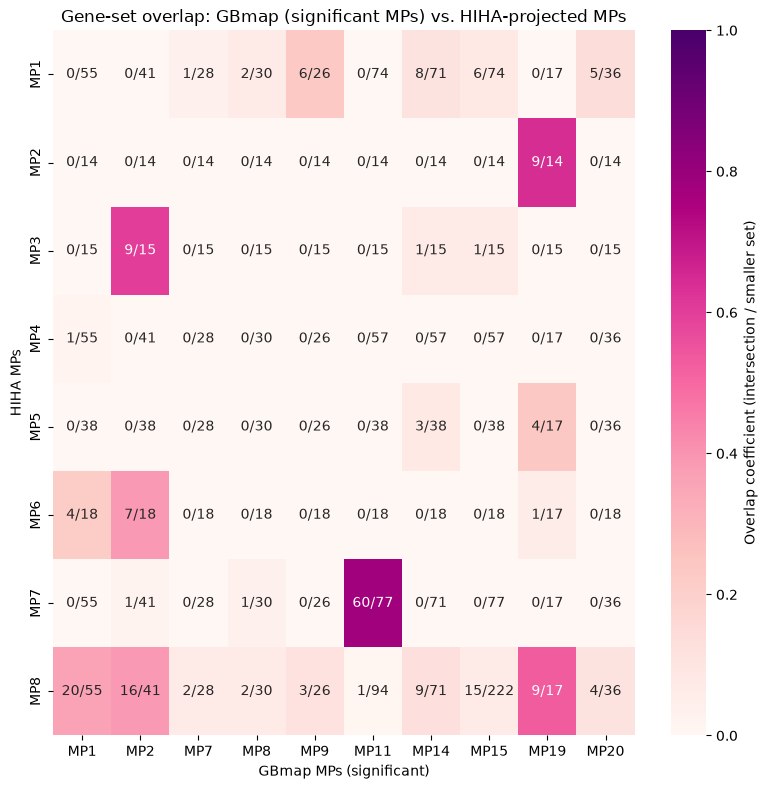

In [16]:
fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(
    overlap_matrix,
    annot=overlap_counts.values,
    fmt="",
    cmap="RdPu",
    vmin=0, vmax=1,
    cbar_kws={"label": "Overlap coefficient (intersection / smaller set)"},
    ax=ax,
)
ax.set_xlabel("GBmap MPs (significant)")
ax.set_ylabel("HIHA MPs")
ax.set_title("Gene-set overlap: GBmap (significant MPs) vs. HIHA-projected MPs", y= 0.9999)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "09_08_gbmap_hiha_gene_overlap.pdf"), bbox_inches="tight", dpi=300)
plt.show()